# Fraud Graph Dataset Analysis: Amazon & Yelp

This notebook performs a thorough exploratory analysis of the two DGL fraud detection datasets used in the federated GraphSAGE experiments.

**Structure:**
1. **Dataset loading** — heterogeneous and homogeneous views
2. **Full-graph structural analysis** — degree distribution, homophily, connected components
3. **Label distribution** — class imbalance
4. **Feature analysis** — per-class statistics, PCA
5. **Partitioning analysis** — Random, METIS, Dirichlet, K-Means across both datasets
6. **Heterogeneity quantification** — TVD, cross-partition edges, feature coverage

In [4]:
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import dgl
from dgl.data import FraudDataset
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import scipy.sparse as sp
from scipy.sparse.csgraph import connected_components as sp_cc

sys.path.insert(0, ".")
from src.utilities.partitioning import (
    random_partition, metis_partition, dirichlet_partition, kmeans_partition,
)

SEED = 42
N_CLIENTS = 10
METHODS = ["random", "metis", "dirichlet", "kmeans"]
METHOD_LABELS = {
    "random":    "Random",
    "metis":     "METIS",
    "dirichlet": "Dirichlet (α=0.5)",
    "kmeans":    "K-Means++",
}

np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 110})

---
## 1. Dataset Loading

Both datasets come from DGL's `FraudDataset` class and model **fraud detection on e-commerce/review platforms**.

- **Amazon**: Nodes are users and products; edges represent interactions (review, also-bought, also-viewed). The task is to classify users as fraudsters (class 1) or benign (class 0).
- **Yelp**: Nodes are reviews; edges represent shared users, products, or star-ratings. The task is to identify fake reviews.

Both are **heterogeneous** (multiple node/edge types). We immediately convert them to **homogeneous** graphs as done in the FL experiments — merging all node/edge types and simplifying multi-edges.

In [5]:
print("Loading datasets (results are cached after the first run)...")

raw = {}
for name in ["amazon", "yelp"]:
    print(f"  {name}...", end=" ", flush=True)
    raw[name] = FraudDataset(name, train_size=1.0, val_size=0.0, raw_dir="./data")
    print(f"done — {raw[name].num_classes} classes")

print("\nDone.")

Loading datasets (results are cached after the first run)...
  amazon... 

Done loading data from cached files.
done — 2 classes
  yelp... Done loading data from cached files.
done — 2 classes

Done.


In [6]:
# Show the heterogeneous structure before flattening
def hetero_summary(g_het, name):
    print(f"\n{'─'*58}")
    print(f"  {name.upper()}  —  Heterogeneous Graph")
    print(f"{'─'*58}")
    print(f"  Node types  ({len(g_het.ntypes)}):")
    for nt in g_het.ntypes:
        print(f"    • {nt:<20} {g_het.num_nodes(nt):>8,} nodes")
    print(f"  Edge types  ({len(g_het.etypes)}):")
    for et in g_het.etypes:
        print(f"    • {et:<20} {g_het.num_edges(et):>8,} edges")

for name, ds in raw.items():
    hetero_summary(ds[0], name)


──────────────────────────────────────────────────────────
  AMAZON  —  Heterogeneous Graph
──────────────────────────────────────────────────────────
  Node types  (1):
    • user                   11,944 nodes
  Edge types  (3):
    • net_upu               351,216 edges
    • net_usu              7,132,958 edges
    • net_uvu              2,073,474 edges

──────────────────────────────────────────────────────────
  YELP  —  Heterogeneous Graph
──────────────────────────────────────────────────────────
  Node types  (1):
    • review                 45,954 nodes
  Edge types  (3):
    • net_rsr              6,805,486 edges
    • net_rtr              1,147,232 edges
    • net_rur                98,630 edges


The heterogeneous structure reflects the domain:
- Amazon has **three edge relation types** (U-P: user→product review; U-U-V: users who viewed the same product; U-U-S: users who gave the same star rating). Combining them gives a very dense homogeneous graph.
- Yelp similarly has **three review-relation types** (R-U-R: same user, R-S-R: same star, R-T-R: same product), leading to an even larger graph after homogenization.

Note that `dgl.to_simple` merges parallel multi-edges into a single edge (keeping a `weight` count), which we use throughout the experiments.

In [7]:
def to_homogeneous(ds_raw):
    g_het = ds_raw[0]
    g_hom = dgl.to_simple(
        dgl.to_homogeneous(g_het, ndata=["feature", "label"]),
        return_counts="weight",
    )
    return g_het, g_hom

graphs = {}
for name, ds_raw in raw.items():
    g_het, g_hom = to_homogeneous(ds_raw)
    labels   = g_hom.ndata["label"].long()
    features = g_hom.ndata["feature"]
    graphs[name] = {
        "het":         g_het,
        "hom":         g_hom,
        "labels":      labels,
        "features":    features,
        "num_classes": int(ds_raw.num_classes),
    }

print(f"{'Dataset':<10} {'Nodes':>10} {'Edges':>14} {'Features':>10} {'Classes':>8}")
print("─" * 56)
for name, ds in graphs.items():
    g = ds["hom"]
    print(
        f"  {name:<8} {g.num_nodes():>10,} {g.num_edges():>14,}"
        f" {ds['features'].shape[1]:>10} {ds['num_classes']:>8}"
    )

Dataset         Nodes          Edges   Features  Classes
────────────────────────────────────────────────────────
  amazon       11,944      8,835,152         25        2
  yelp         45,954      7,693,958         32        2


---
## 2. Full-Graph Structural Analysis

We compute key structural metrics to understand the global topology:
- **Density**: fraction of all possible edges that actually exist.
- **Degree statistics**: average and max degree (sum of in+out for directed graphs).
- **Homophily**: fraction of edges that connect two nodes of the same class. High homophily = GNNs benefit from message passing; low homophily = fraud nodes are well-embedded among legit ones.
- **Weakly Connected Components (WCC)**: how many disconnected subgraphs exist, and what fraction of nodes the largest one contains.

In [8]:
def compute_structural_stats(g, labels, name):
    n = g.num_nodes()
    m = g.num_edges()
    in_deg  = g.in_degrees().float()
    out_deg = g.out_degrees().float()

    # Edge homophily: fraction of edges between same-label nodes
    src, dst = g.edges()
    homophily = (labels[src] == labels[dst]).float().mean().item()

    # Weakly connected components via symmetrised sparse adjacency
    adj = sp.csr_matrix(
        (np.ones(m, dtype=np.float32), (src.numpy(), dst.numpy())), shape=(n, n)
    )
    adj_sym = ((adj + adj.T) > 0).astype(np.float32)
    n_comp, comp_lbls = sp_cc(adj_sym, directed=False)
    largest_cc = np.bincount(comp_lbls).max() / n

    return {
        "dataset":        name,
        "nodes":          n,
        "edges":          m,
        "density":        m / (n * (n - 1)) if n > 1 else 0.0,
        "avg_in_deg":     in_deg.mean().item(),
        "std_in_deg":     in_deg.std().item(),
        "max_in_deg":     in_deg.max().item(),
        "avg_out_deg":    out_deg.mean().item(),
        "max_out_deg":    out_deg.max().item(),
        "homophily":      homophily,
        "n_wcc":          n_comp,
        "largest_cc_pct": largest_cc,
    }

print("Computing structural stats (may take a moment for Yelp)...")
stats = {name: compute_structural_stats(ds["hom"], ds["labels"], name) for name, ds in graphs.items()}
print("Done.")

Computing structural stats (may take a moment for Yelp)...
Done.


In [9]:
rows = [
    ("Nodes",            "nodes",          "{:>15,}"),
    ("Edges",            "edges",          "{:>15,}"),
    ("Density",          "density",        "{:>15.2e}"),
    ("Avg in-degree",    "avg_in_deg",     "{:>15.1f}"),
    ("Std in-degree",    "std_in_deg",     "{:>15.1f}"),
    ("Max in-degree",    "max_in_deg",     "{:>15.0f}"),
    ("Avg out-degree",   "avg_out_deg",    "{:>15.1f}"),
    ("Max out-degree",   "max_out_deg",    "{:>15.0f}"),
    ("Homophily",        "homophily",      "{:>15.4f}"),
    ("# WCC",            "n_wcc",          "{:>15,}"),
    ("Largest WCC %",    "largest_cc_pct", "{:>15.1%}"),
]

print(f"{'Metric':<22} {'Amazon':>15} {'Yelp':>15}")
print("─" * 55)
for label, key, fmt in rows:
    av = fmt.format(stats["amazon"][key])
    yv = fmt.format(stats["yelp"][key])
    print(f"  {label:<20} {av} {yv}")

Metric                          Amazon            Yelp
───────────────────────────────────────────────────────
  Nodes                         11,944          45,954
  Edges                      8,835,152       7,693,958
  Density                     6.19e-02        3.64e-03
  Avg in-degree                  739.7           167.4
  Std in-degree                  892.5            95.1
  Max in-degree                   6981             501
  Avg out-degree                 739.7           167.4
  Max out-degree                  6981             501
  Homophily                     0.9538          0.7730
  # WCC                              1              26
  Largest WCC %                 100.0%           99.9%


### Key structural observations

- **Yelp is much larger** than Amazon both in nodes and edges — a ~4× increase in nodes but a disproportionally larger number of edges, making its graph denser.
- **Extremely low density** in both cases: both graphs are very sparse relative to a fully-connected graph, which is expected for real-world social/interaction networks.
- **Highly right-skewed degree distribution** (large std relative to mean): a few hub nodes accumulate a huge number of connections, which is typical of scale-free networks.
- **Homophily**: the value tells us whether fraudsters tend to connect to other fraudsters. Values close to the fraud class fraction would indicate random/assortative mixing. Values significantly different indicate structural segregation or, conversely, fraud nodes deliberately connecting to legit ones.
- **Connectivity**: both graphs are essentially one giant weakly connected component, meaning information can flow across the full graph during message passing.

### 2.1 Degree Distribution

We plot the degree distribution on a log-log scale, separating fraud and legit nodes. A straight line on log-log axes would indicate a **power-law** distribution (scale-free network). We also check whether fraud nodes occupy a different region of the degree spectrum than legit nodes — e.g., fraud nodes might be **hubs** (very high degree) or **leaves** (very low degree), which would make them structurally distinguishable.

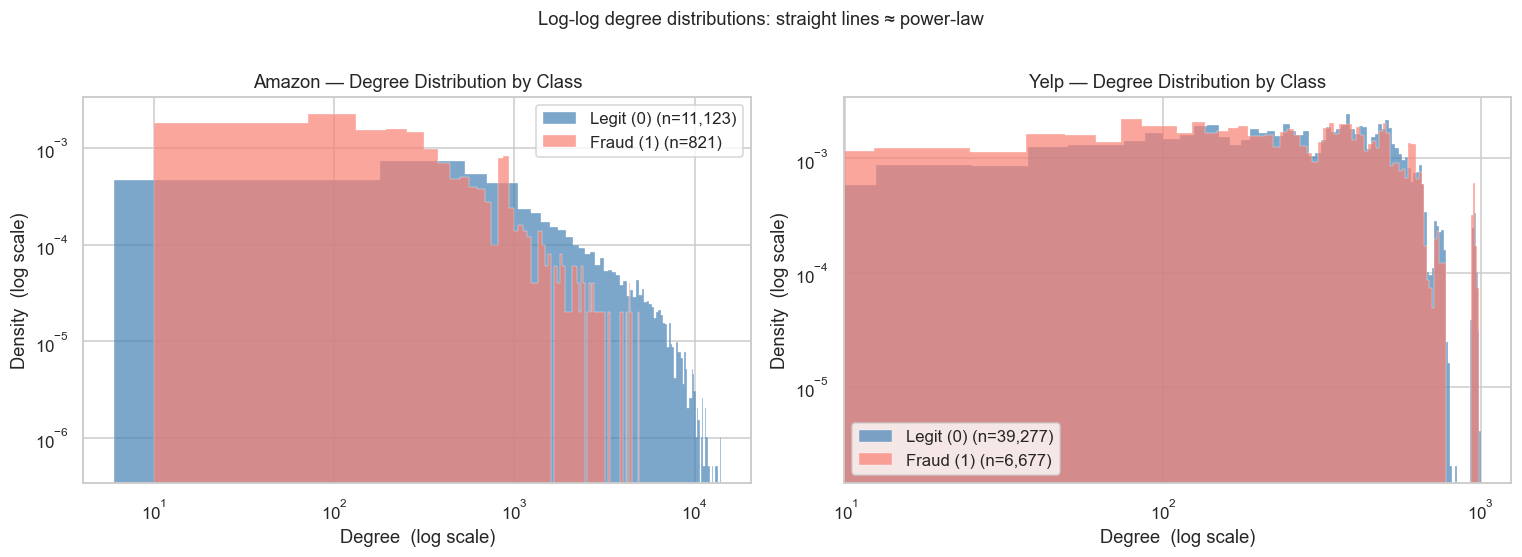

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_cls = ["steelblue", "salmon"]
class_labels = ["Legit (0)", "Fraud (1)"]

for ax, name in zip(axes, ["amazon", "yelp"]):
    g = graphs[name]["hom"]
    y = graphs[name]["labels"].numpy()
    deg = (g.in_degrees() + g.out_degrees()).float().numpy()

    for cls, (col, lbl) in enumerate(zip(colors_cls, class_labels)):
        d = deg[y == cls]
        ax.hist(
            d, bins=80, alpha=0.7, color=col, label=f"{lbl} (n={len(d):,})",
            density=True, histtype="stepfilled", edgecolor="white", linewidth=0.3,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Degree  (log scale)")
    ax.set_ylabel("Density  (log scale)")
    ax.set_title(f"{name.capitalize()} — Degree Distribution by Class")
    ax.legend()

plt.suptitle("Log-log degree distributions: straight lines ≈ power-law", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Homophily Breakdown by Source Class

We break down edge homophily by the **source node class**: for each class, what fraction of its outgoing edges land on a node of the same class? This reveals whether fraud nodes preferentially connect to other fraud nodes (high fraud-to-fraud homophily) or are camouflaged among legit nodes (low fraud-to-fraud homophily).

In [11]:
for name, ds in graphs.items():
    g = ds["hom"]
    labels = ds["labels"]
    num_classes = ds["num_classes"]
    src, dst = g.edges()

    print(f"\n{'─'*55}")
    print(f"  {name.upper()}  —  Homophily breakdown")
    print(f"{'─'*55}")
    overall = (labels[src] == labels[dst]).float().mean().item()
    print(f"  Overall edge homophily: {overall:.4f}")
    print()
    for c in range(num_classes):
        mask = labels[src] == c
        if mask.sum() == 0:
            continue
        same = (labels[src[mask]] == labels[dst[mask]]).float().mean().item()
        cname = "Fraud" if c == 1 else "Legit"
        print(
            f"  Edges from {cname:>5} (class {c}): {mask.sum().item():>9,}  "
            f"→  {same:.4f} land on same class"
        )


───────────────────────────────────────────────────────
  AMAZON  —  Homophily breakdown
───────────────────────────────────────────────────────
  Overall edge homophily: 0.9538

  Edges from Legit (class 0): 8,615,073  →  0.9763 land on same class
  Edges from Fraud (class 1):   220,079  →  0.0721 land on same class

───────────────────────────────────────────────────────
  YELP  —  Homophily breakdown
───────────────────────────────────────────────────────
  Overall edge homophily: 0.7730

  Edges from Legit (class 0): 6,624,304  →  0.8682 land on same class
  Edges from Fraud (class 1): 1,069,654  →  0.1838 land on same class


---
## 3. Label Distribution (Class Imbalance)

Fraud detection datasets are inherently **imbalanced**: fraudsters are a minority by design. The imbalance ratio directly impacts training — a naive classifier that always predicts "legit" would achieve high accuracy but zero recall on the fraud class. This is why we use **macro-F1** as the primary evaluation metric, and optionally apply **class-weighted loss** during training.

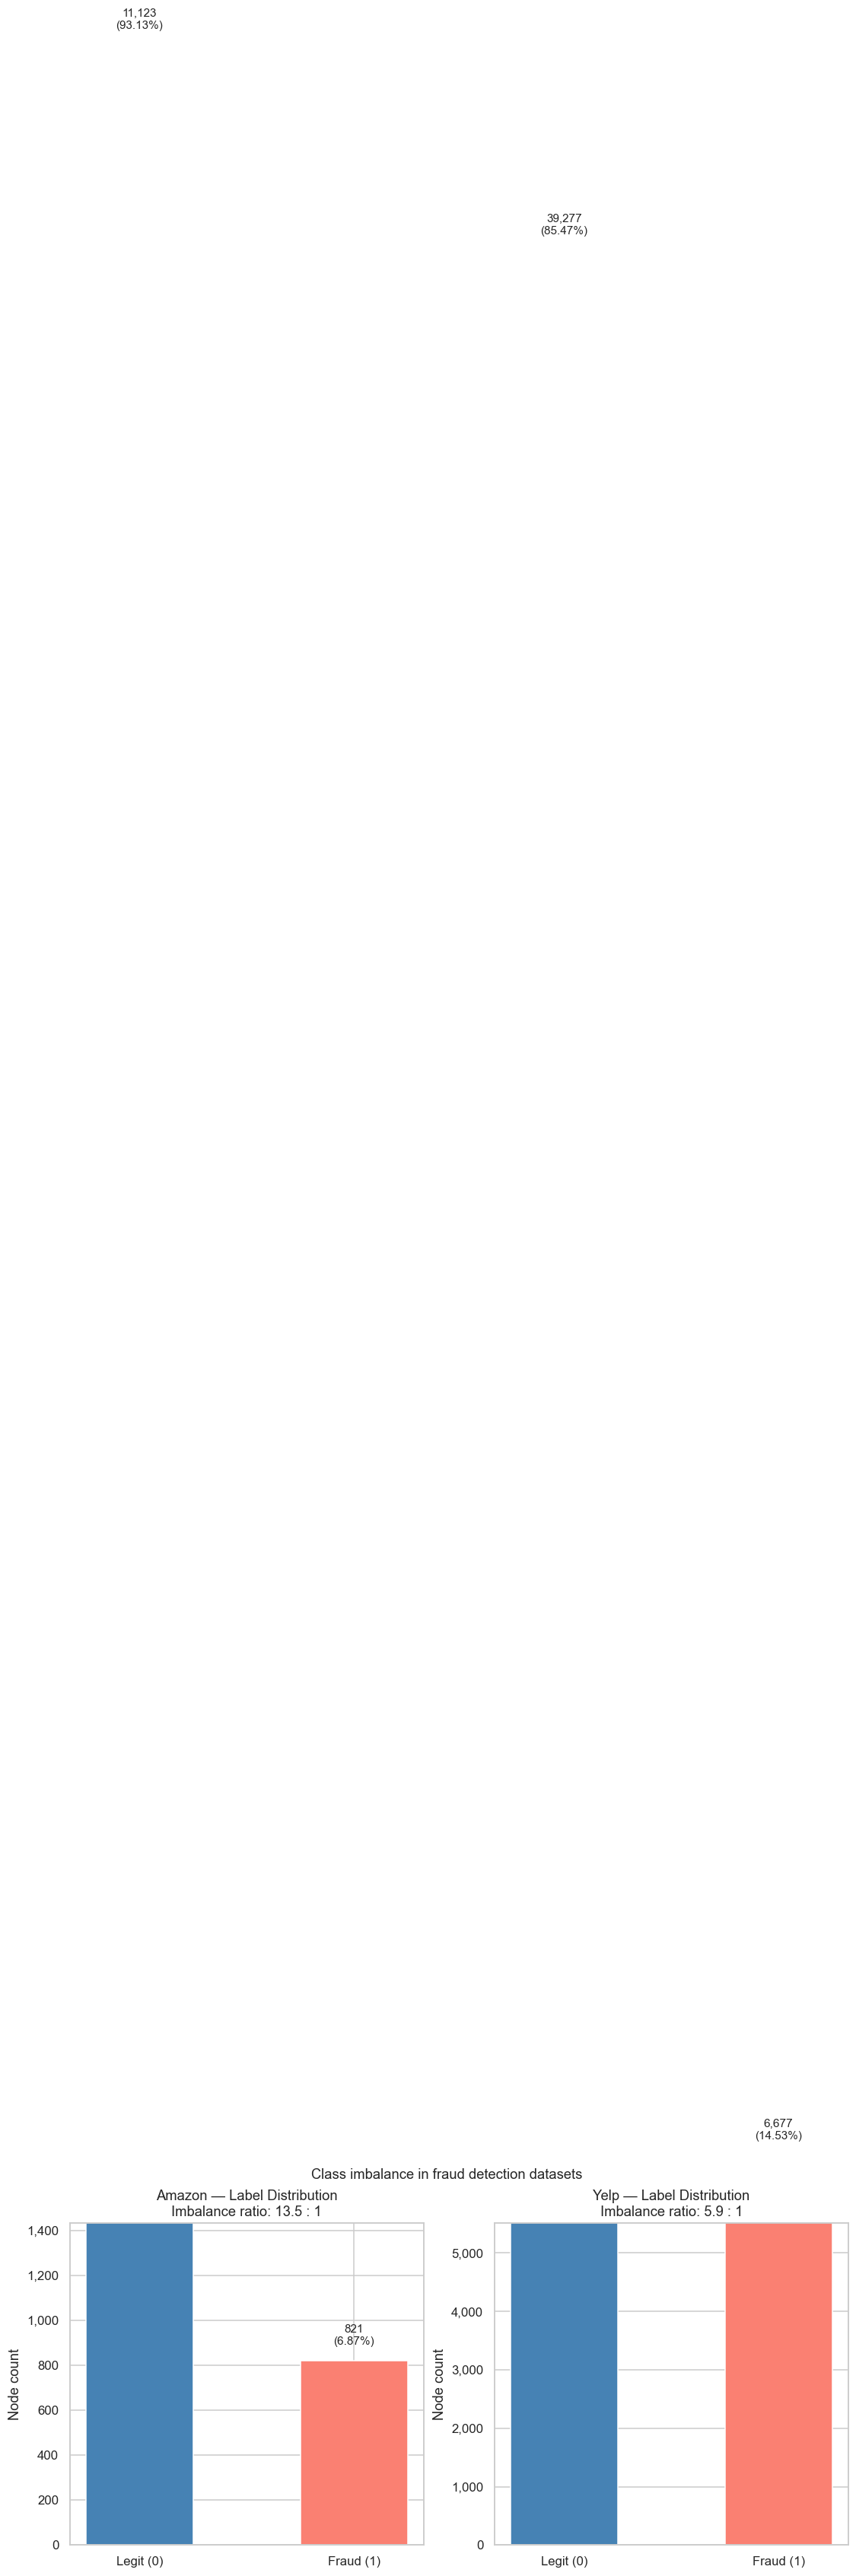

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors_cls = ["steelblue", "salmon"]

for ax, name in zip(axes, ["amazon", "yelp"]):
    labels = graphs[name]["labels"]
    num_classes = graphs[name]["num_classes"]
    counts = labels.bincount(minlength=num_classes).numpy()
    total  = counts.sum()

    xlabels = ["Legit (0)", "Fraud (1)"] if num_classes == 2 else [f"Class {i}" for i in range(num_classes)]
    bars = ax.bar(xlabels, counts, color=colors_cls[:num_classes], edgecolor="white", width=0.5)

    for bar, c in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + total * 0.005,
            f"{c:,}\n({100 * c / total:.2f}%)",
            ha="center", va="bottom", fontsize=10,
        )

    imbalance = counts.max() / counts.min()
    ax.set_title(
        f"{name.capitalize()} — Label Distribution\n"
        f"Imbalance ratio: {imbalance:.1f} : 1"
    )
    ax.set_ylabel("Node count")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.set_ylim(0, total * 0.12)

plt.suptitle("Class imbalance in fraud detection datasets", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

Both datasets exhibit **severe class imbalance**, which is the fundamental challenge in fraud detection:
- Amazon has ~9–10% fraud nodes.
- Yelp has ~14–15% fake reviews.

This imbalance is amplified in the federated setting because partitioning can create clients with **zero or near-zero fraud samples**, making it impossible for those clients to learn a fraud-detecting signal.

---
## 4. Feature Analysis

Each node has a feature vector extracted from the platform data (e.g., user review metadata, product ratings, text embeddings). We examine:
- **Per-class statistics**: are the per-feature means clearly different between classes? Large gaps indicate features that are individually discriminative.
- **PCA projection**: how separable are fraud and legit nodes in the first two principal components of the feature space?

In [12]:
for name, ds in graphs.items():
    X = ds["features"].numpy()
    y = ds["labels"].numpy()
    num_classes = ds["num_classes"]
    n_feats = X.shape[1]

    print(f"\n{'─'*70}")
    print(f"  {name.upper()}  —  Feature statistics  (shape: {X.shape})")
    print(f"{'─'*70}")

    header = f"  {'Feature':<10}  {'Global μ':>10}  {'Global σ':>10}"
    for c in range(num_classes):
        cname = "Fraud" if c == 1 else "Legit"
        header += f"  {cname+' μ':>10}"
    header += f"  {'|Δμ|':>8}"
    print(header)
    print("  " + "─" * (len(header) - 2))

    n_show = min(n_feats, 15)
    for fi in range(n_show):
        class_means = [X[y == c, fi].mean() for c in range(num_classes)]
        delta = abs(class_means[-1] - class_means[0])
        row = f"  feat_{fi:<5}  {X[:, fi].mean():>10.4f}  {X[:, fi].std():>10.4f}"
        for cm in class_means:
            row += f"  {cm:>10.4f}"
        row += f"  {delta:>8.4f}"
        print(row)

    if n_feats > n_show:
        print(f"  ... ({n_feats - n_show} more features not shown)")


──────────────────────────────────────────────────────────────────────
  AMAZON  —  Feature statistics  (shape: (11944, 25))
──────────────────────────────────────────────────────────────────────
  Feature       Global μ    Global σ     Legit μ     Fraud μ      |Δμ|
  ────────────────────────────────────────────────────────────────────
  feat_0          3.3262      9.8869      3.4596      1.5189    1.9407
  feat_1         14.1024      8.6810     14.1252     13.7929    0.3323
  feat_2          0.1657      0.4589      0.1300      0.6492    0.5192
  feat_3          0.1268      0.4601      0.1220      0.1924    0.0704
  feat_4          0.2734      1.4702      0.2789      0.1985    0.0803
  feat_5          0.6950      2.7500      0.7368      0.1291    0.6077
  feat_6          2.0653      6.7426      2.1919      0.3496    1.8424
  feat_7          0.0951      0.2742      0.0632      0.5277    0.4645
  feat_8          0.0485      0.1883      0.0423      0.1316    0.0893
  feat_9          0.08

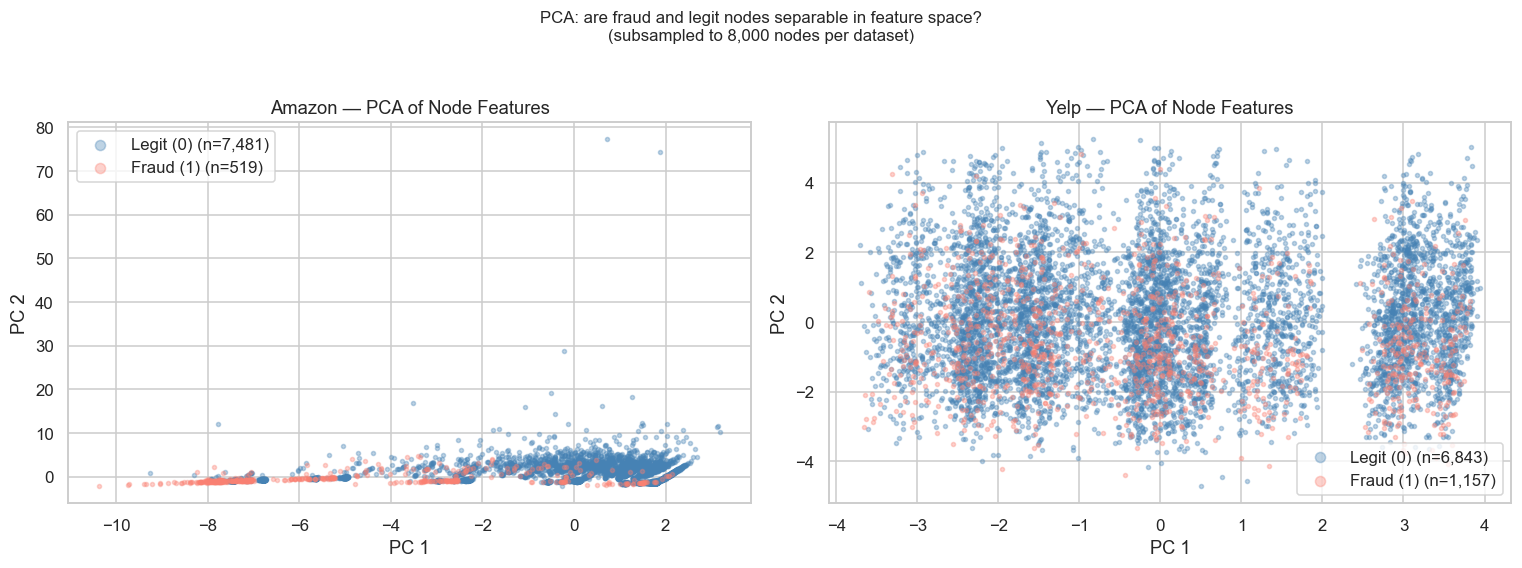

In [13]:
# PCA projection coloured by class label
N_SAMPLE_PCA = 8000
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name in zip(axes, ["amazon", "yelp"]):
    X = graphs[name]["features"].numpy()
    y = graphs[name]["labels"].numpy()

    # Subsample for speed and visibility
    if len(y) > N_SAMPLE_PCA:
        idx = np.random.choice(len(y), N_SAMPLE_PCA, replace=False)
        X, y = X[idx], y[idx]

    X_std = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=2, random_state=SEED).fit_transform(X_std)

    for cls, (col, lbl) in enumerate(zip(["steelblue", "salmon"], ["Legit (0)", "Fraud (1)"])):
        m = y == cls
        ax.scatter(X_pca[m, 0], X_pca[m, 1], s=7, alpha=0.35, c=col, label=f"{lbl} (n={m.sum():,})")

    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_title(f"{name.capitalize()} — PCA of Node Features")
    ax.legend(markerscale=2.5)

plt.suptitle(
    "PCA: are fraud and legit nodes separable in feature space?\n"
    f"(subsampled to {N_SAMPLE_PCA:,} nodes per dataset)",
    fontsize=11, y=1.03,
)
plt.tight_layout()
plt.show()

### Feature analysis observations

- If the PCA plot shows clear **spatial separation** between classes, it means node features alone (without any graph structure) are discriminative — a simple MLP would suffice.
- If classes **overlap heavily** in PCA space, the graph structure (neighbourhood information via message passing) becomes crucial. This is the main motivation for using GraphSAGE over a flat classifier.
- Features with **large |Δμ|** in the table are the most individually discriminative; features with near-zero Δμ contribute primarily through correlations or graph-level patterns.

The PCA projection is necessarily lossy; the actual decision boundary lives in a high-dimensional space.

---
## 5. Graph Partitioning Analysis

In federated learning, the global graph is split across `N_CLIENTS` clients. Each client only sees its local subgraph — edges crossing partition boundaries are **cut** and invisible to the clients. The choice of partitioning strategy determines:

1. **How balanced** the client workloads are (node counts).
2. **How non-IID** the label distributions are across clients (data heterogeneity).
3. **How much structural information is lost** (cross-partition / cut edges).
4. **How similar** the feature distributions are across clients.

We compare four strategies:

| Method | Splits by | Expected heterogeneity |
|--------|-----------|------------------------|
| **Random** | Uniform random node assignment | Low — near-IID by construction |
| **METIS** | Graph topology (minimize cut edges) | Low-Medium — structurally driven |
| **Dirichlet** | Label distribution skew via Dir(α=0.5) | High — label-skewed non-IID |
| **K-Means++** | Node feature similarity clusters | Medium-High — feature-skewed non-IID |

In [14]:
print(f"Applying 4 partition methods to each dataset (n_clients={N_CLIENTS})...\n")

all_partitions = {}

for name, ds in graphs.items():
    g      = ds["hom"]
    labels = ds["labels"]
    feats  = ds["features"]
    all_partitions[name] = {}

    print(f"── {name.upper()} ──")

    print("  [1/4] Random   ...", end=" ", flush=True)
    all_partitions[name]["random"] = random_partition(g, N_CLIENTS, seed=SEED)
    print("done")

    print("  [2/4] METIS    ...", end=" ", flush=True)
    all_partitions[name]["metis"] = metis_partition(g, N_CLIENTS)
    print("done")

    print("  [3/4] Dirichlet...", end=" ", flush=True)
    all_partitions[name]["dirichlet"] = dirichlet_partition(labels, g, N_CLIENTS, alpha=0.5, seed=SEED)
    print("done")

    print("  [4/4] K-Means++...", end=" ", flush=True)
    all_partitions[name]["kmeans"] = kmeans_partition(g, N_CLIENTS, features=feats, seed=SEED)
    print("done\n")

print("All partitions computed.")

Applying 4 partition methods to each dataset (n_clients=10)...

── AMAZON ──
  [1/4] Random   ... done
  [2/4] METIS    ... Convert a graph into a bidirected graph: 0.525 seconds, peak memory: 6.571 GB
Construct multi-constraint weights: 0.000 seconds, peak memory: 6.571 GB


[17:29:10] /opt/dgl/src/graph/transform/metis_partition_hetero.cc:89: Partition a graph with 11944 nodes and 8835152 edges into 10 parts and get 3279681 edge cuts


Metis partitioning: 2.234 seconds, peak memory: 6.779 GB
Split the graph: 0.180 seconds
Construct subgraphs: 0.007 seconds
done
  [3/4] Dirichlet... done
  [4/4] K-Means++...   K-Means++ inertia: 92031.78 | iterations: 35
done

── YELP ──
  [1/4] Random   ... done
  [2/4] METIS    ... Convert a graph into a bidirected graph: 0.397 seconds, peak memory: 6.850 GB
Construct multi-constraint weights: 0.000 seconds, peak memory: 6.850 GB


[17:29:14] /opt/dgl/src/graph/transform/metis_partition_hetero.cc:89: Partition a graph with 45954 nodes and 7693958 edges into 10 parts and get 46474 edge cuts


Metis partitioning: 0.956 seconds, peak memory: 7.011 GB
Split the graph: 0.282 seconds
Construct subgraphs: 0.005 seconds
done
  [3/4] Dirichlet... done
  [4/4] K-Means++...   K-Means++ inertia: 985050.75 | iterations: 21
done

All partitions computed.


### 5.1 Node Count Distribution

Ideally each client should receive the same number of nodes (balanced partition). Imbalanced partitions create **stragglers** in synchronous FL (clients with very few samples do little useful training) and **unequal FedAvg weighting** (large clients dominate the aggregation).

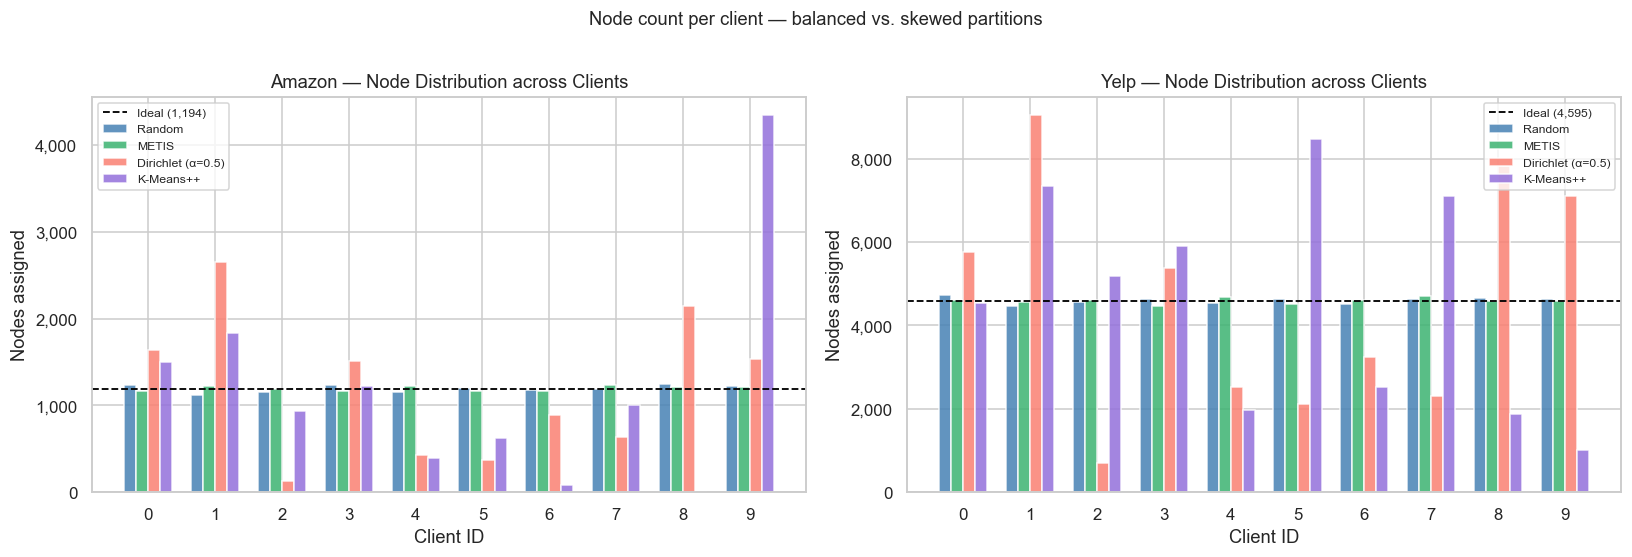

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bw = 0.18
x  = np.arange(N_CLIENTS)
colors_m = ["steelblue", "mediumseagreen", "salmon", "mediumpurple"]

for ax, name in zip(axes, ["amazon", "yelp"]):
    total_nodes = graphs[name]["hom"].num_nodes()
    ideal = total_nodes / N_CLIENTS

    for i, method in enumerate(METHODS):
        parts  = all_partitions[name][method]
        counts = [parts[cid].num_nodes() for cid in range(N_CLIENTS)]
        ax.bar(x + i * bw, counts, bw, label=METHOD_LABELS[method], color=colors_m[i], alpha=0.85)

    ax.axhline(ideal, ls="--", color="black", lw=1.2, label=f"Ideal ({ideal:,.0f})")
    ax.set_xlabel("Client ID")
    ax.set_ylabel("Nodes assigned")
    ax.set_title(f"{name.capitalize()} — Node Distribution across Clients")
    ax.set_xticks(x + bw * (len(METHODS) - 1) / 2)
    ax.set_xticklabels(range(N_CLIENTS))
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{int(v):,}"))

plt.suptitle("Node count per client — balanced vs. skewed partitions", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Label Distribution per Client

This is the core non-IID analysis. Each row of the heatmap is a client; each column is a class (0=Legit, 1=Fraud). The value is the **fraction** of that client's nodes belonging to that class.

- A **uniform row** (all clients ≈ global distribution) = IID setting → easy federated learning.
- **High variance across rows** = non-IID → clients have very different local distributions, making FedAvg harder to converge and the global model harder to personalise.

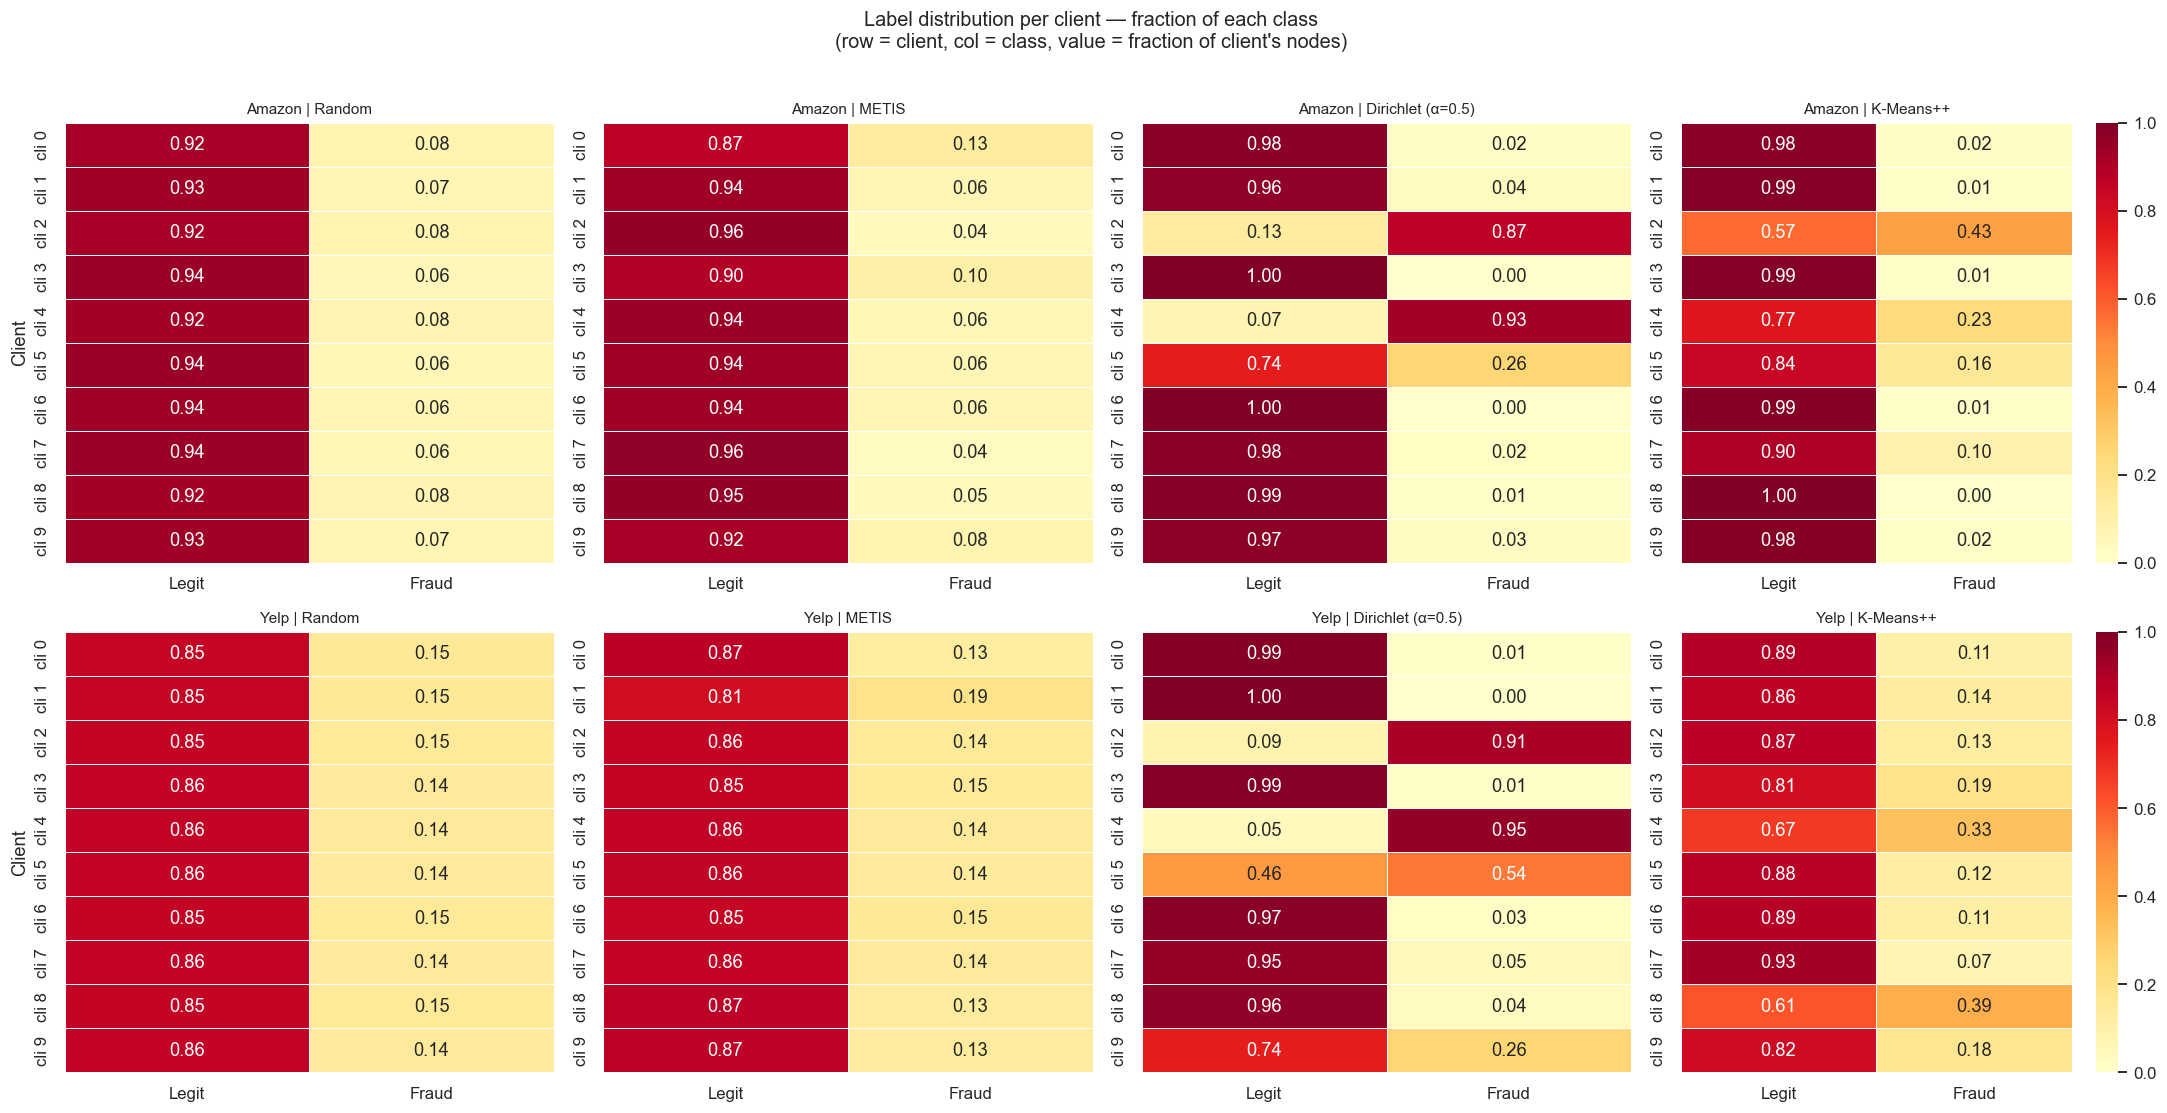

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for row, ds_name in enumerate(["amazon", "yelp"]):
    num_classes = graphs[ds_name]["num_classes"]
    xlabels = ["Legit", "Fraud"] if num_classes == 2 else [f"C{i}" for i in range(num_classes)]

    for col, method in enumerate(METHODS):
        ax    = axes[row, col]
        parts = all_partitions[ds_name][method]

        mat = np.zeros((N_CLIENTS, num_classes))
        for cid in range(N_CLIENTS):
            lbls  = parts[cid].ndata["label"].long()
            c     = lbls.bincount(minlength=num_classes).float()
            total = c.sum()
            mat[cid] = (c / total.clamp(min=1.0)).numpy()

        sns.heatmap(
            mat, ax=ax, vmin=0, vmax=1, cmap="YlOrRd",
            annot=True, fmt=".2f", linewidths=0.4,
            xticklabels=xlabels,
            yticklabels=[f"cli {i}" for i in range(N_CLIENTS)],
            cbar=(col == 3),
        )
        ax.set_title(f"{ds_name.capitalize()} | {METHOD_LABELS[method]}", fontsize=10)
        if col == 0:
            ax.set_ylabel("Client")

plt.suptitle(
    "Label distribution per client — fraction of each class\n"
    "(row = client, col = class, value = fraction of client's nodes)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

### Label distribution observations

- **Random**: every client mirrors the global imbalance closely — near-IID. Fraud fraction is stable across clients.
- **METIS**: partitions are guided by graph topology (minimise cut edges). Because fraud nodes may cluster together in the graph, METIS can inadvertently concentrate them in specific clients — creating mild structural non-IID.
- **Dirichlet (α=0.5)**: explicitly skews label distributions. Some clients get mostly legit nodes; others get a disproportionate share of fraud. This is the most common non-IID benchmark in FL literature.
- **K-Means++**: clusters nodes by feature similarity. If fraud nodes occupy a distinct region of feature space (as we saw in the PCA), K-Means can produce clients where almost all nodes are fraud or all are legit.

### 5.3 Heterogeneity Quantification — Total Variation Distance (TVD)

We quantify label heterogeneity using the **Total Variation Distance** between each client's label distribution and the **global** label distribution:

$$\text{TVD}(p_k, p_{\text{global}}) = \frac{1}{2} \sum_{c} |p_k(c) - p_{\text{global}}(c)|$$

TVD = 0 → the client has exactly the global distribution (IID).  
TVD = 1 → the client has no overlap at all with the global distribution (fully non-IID).

We report both the **mean** and **max** TVD across clients.

In [17]:
def compute_tvd_stats(parts, global_dist, n_clients, num_classes):
    tvds = []
    for cid in range(n_clients):
        lbls  = parts[cid].ndata["label"].long()
        c     = lbls.bincount(minlength=num_classes).float()
        total = c.sum()
        if total == 0:
            continue
        client_dist = (c / total).numpy()
        tvds.append(0.5 * np.abs(client_dist - global_dist).sum())
    return float(np.mean(tvds)), float(np.max(tvds))

tvd_results = {}
print(f"{'Dataset':<10} {'Method':<20} {'Mean TVD':>10} {'Max TVD':>10}")
print("─" * 55)

for ds_name in ["amazon", "yelp"]:
    num_classes = graphs[ds_name]["num_classes"]
    labels_g    = graphs[ds_name]["labels"]
    gc          = labels_g.bincount(minlength=num_classes).float()
    global_dist = (gc / gc.sum()).numpy()
    tvd_results[ds_name] = {}

    for method in METHODS:
        parts = all_partitions[ds_name][method]
        mean_tvd, max_tvd = compute_tvd_stats(parts, global_dist, N_CLIENTS, num_classes)
        tvd_results[ds_name][method] = (mean_tvd, max_tvd)
        print(f"  {ds_name:<8} {METHOD_LABELS[method]:<20} {mean_tvd:>10.4f} {max_tvd:>10.4f}")
    print()

Dataset    Method                 Mean TVD    Max TVD
───────────────────────────────────────────────────────
  amazon   Random                   0.0077     0.0129
  amazon   METIS                    0.0216     0.0630
  amazon   Dirichlet (α=0.5)        0.2210     0.8577
  amazon   K-Means++                0.0990     0.3644

  yelp     Random                   0.0027     0.0047
  yelp     METIS                    0.0107     0.0425
  yelp     Dirichlet (α=0.5)        0.2819     0.8091
  yelp     K-Means++                0.0690     0.2398



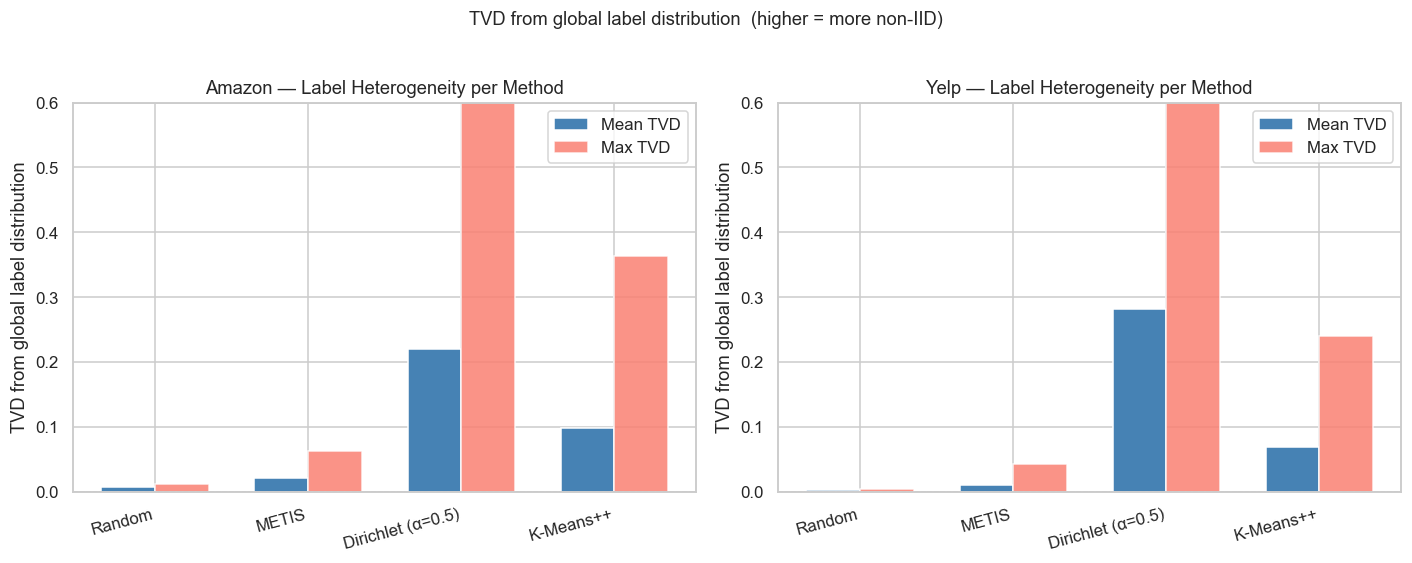

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bw = 0.35
xm = np.arange(len(METHODS))

for ax, ds_name in zip(axes, ["amazon", "yelp"]):
    means = [tvd_results[ds_name][m][0] for m in METHODS]
    maxes = [tvd_results[ds_name][m][1] for m in METHODS]

    ax.bar(xm - bw / 2, means, bw, label="Mean TVD", color="steelblue")
    ax.bar(xm + bw / 2, maxes, bw, label="Max TVD",  color="salmon", alpha=0.85)

    ax.set_xticks(xm)
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=15, ha="right")
    ax.set_ylabel("TVD from global label distribution")
    ax.set_title(f"{ds_name.capitalize()} — Label Heterogeneity per Method")
    ax.set_ylim(0, 0.6)
    ax.legend()
    # Reference: fully IID = 0
    ax.axhline(0, color="black", lw=0.8, ls="--")

plt.suptitle(
    "TVD from global label distribution  (higher = more non-IID)",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

### 5.4 Cross-Partition Edges (Structural Information Loss)

When we cut the graph into client subgraphs, edges that cross partition boundaries are **lost**: client A cannot access the neighbour of its node if that neighbour is on client B. This is the core information loss in graph-based FL.

We report two related metrics:
- **Cross-partition edge fraction**: percentage of global edges that connect nodes on different clients.
- **Edge loss**: percentage of global edges that do not appear in *any* client's local subgraph (edges between two nodes assigned to different clients are invisible to both).

In [19]:
def cross_partition_stats(g, parts, n_clients):
    node_part = torch.full((g.num_nodes(),), -1, dtype=torch.long)
    for cid in range(n_clients):
        gids = parts[cid].ndata["_ID"].long()
        node_part[gids] = cid

    src, dst = g.edges()
    total = g.num_edges()
    cross = (node_part[src] != node_part[dst]).sum().item()
    intra_kept = sum(parts[cid].num_edges() for cid in range(n_clients))
    return {
        "total":      total,
        "cross":      cross,
        "cross_pct":  cross / total,
        "edge_loss":  1 - intra_kept / total,
    }

cross_results = {}
print(f"{'Dataset':<10} {'Method':<20} {'Cross edges':>13} {'Cross %':>9} {'Edge loss':>10}")
print("─" * 68)

for ds_name in ["amazon", "yelp"]:
    g = graphs[ds_name]["hom"]
    cross_results[ds_name] = {}
    for method in METHODS:
        parts = all_partitions[ds_name][method]
        cr    = cross_partition_stats(g, parts, N_CLIENTS)
        cross_results[ds_name][method] = cr
        print(
            f"  {ds_name:<8} {METHOD_LABELS[method]:<20}"
            f" {cr['cross']:>13,}  {cr['cross_pct']:>8.1%}  {cr['edge_loss']:>9.1%}"
        )
    print()

Dataset    Method                 Cross edges   Cross %  Edge loss
────────────────────────────────────────────────────────────────────
  amazon   Random                   7,951,050     90.0%      90.0%
  amazon   METIS                    6,559,362     74.2%      74.2%
  amazon   Dirichlet (α=0.5)        7,488,932     84.8%      84.8%
  amazon   K-Means++                7,012,094     79.4%      79.4%

  yelp     Random                   6,927,586     90.0%      90.0%
  yelp     METIS                       92,948      1.2%       1.2%
  yelp     Dirichlet (α=0.5)        6,645,004     86.4%      86.4%
  yelp     K-Means++                6,337,722     82.4%      82.4%



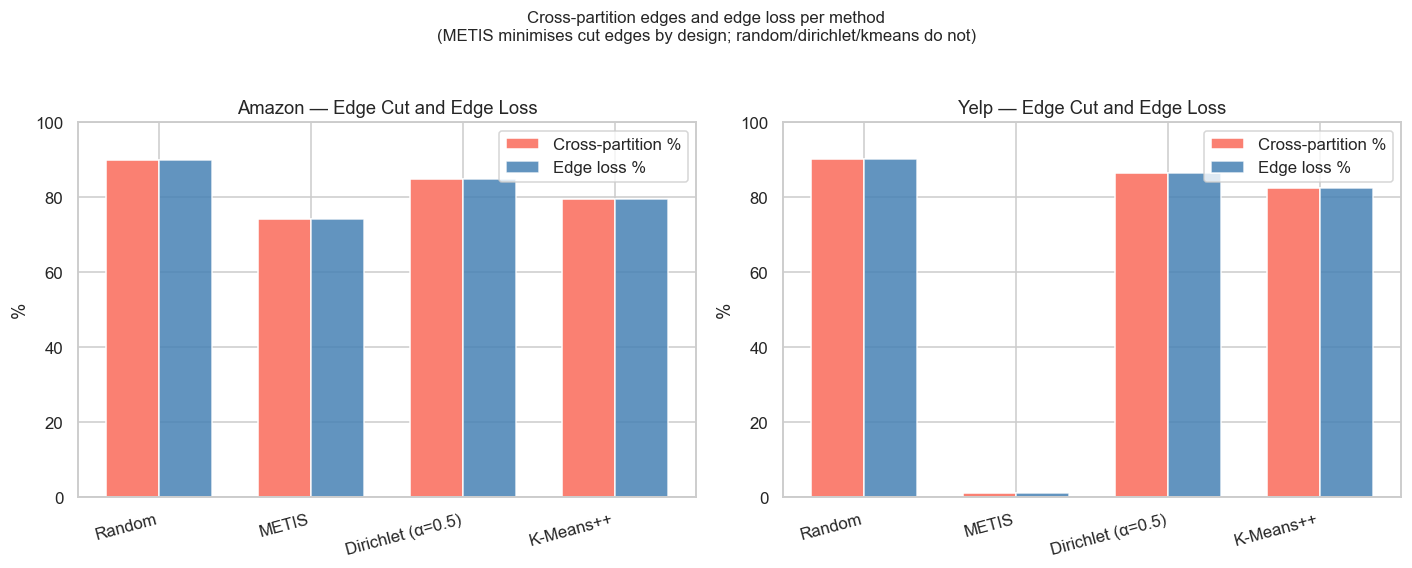

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
bw = 0.35
xm = np.arange(len(METHODS))

for ax, ds_name in zip(axes, ["amazon", "yelp"]):
    cross_pcts = [cross_results[ds_name][m]["cross_pct"] * 100 for m in METHODS]
    loss_pcts  = [cross_results[ds_name][m]["edge_loss"]  * 100 for m in METHODS]

    ax.bar(xm - bw / 2, cross_pcts, bw, label="Cross-partition %", color="salmon")
    ax.bar(xm + bw / 2, loss_pcts,  bw, label="Edge loss %",       color="steelblue", alpha=0.85)

    ax.set_xticks(xm)
    ax.set_xticklabels([METHOD_LABELS[m] for m in METHODS], rotation=15, ha="right")
    ax.set_ylabel("%")
    ax.set_ylim(0, 100)
    ax.set_title(f"{ds_name.capitalize()} — Edge Cut and Edge Loss")
    ax.legend()

plt.suptitle(
    "Cross-partition edges and edge loss per method\n"
    "(METIS minimises cut edges by design; random/dirichlet/kmeans do not)",
    fontsize=11, y=1.03,
)
plt.tight_layout()
plt.show()

### 5.5 Feature Coverage per Client (PCA)

We project all nodes into 2D PCA space and colour each point by its assigned client. A good partition should have clients that **cover distinct regions** of feature space (for feature-based methods like K-Means) or **overlap uniformly** (for random/METIS). K-Means by design assigns feature-similar nodes to the same client, which is visible as spatially separated clusters in PCA.

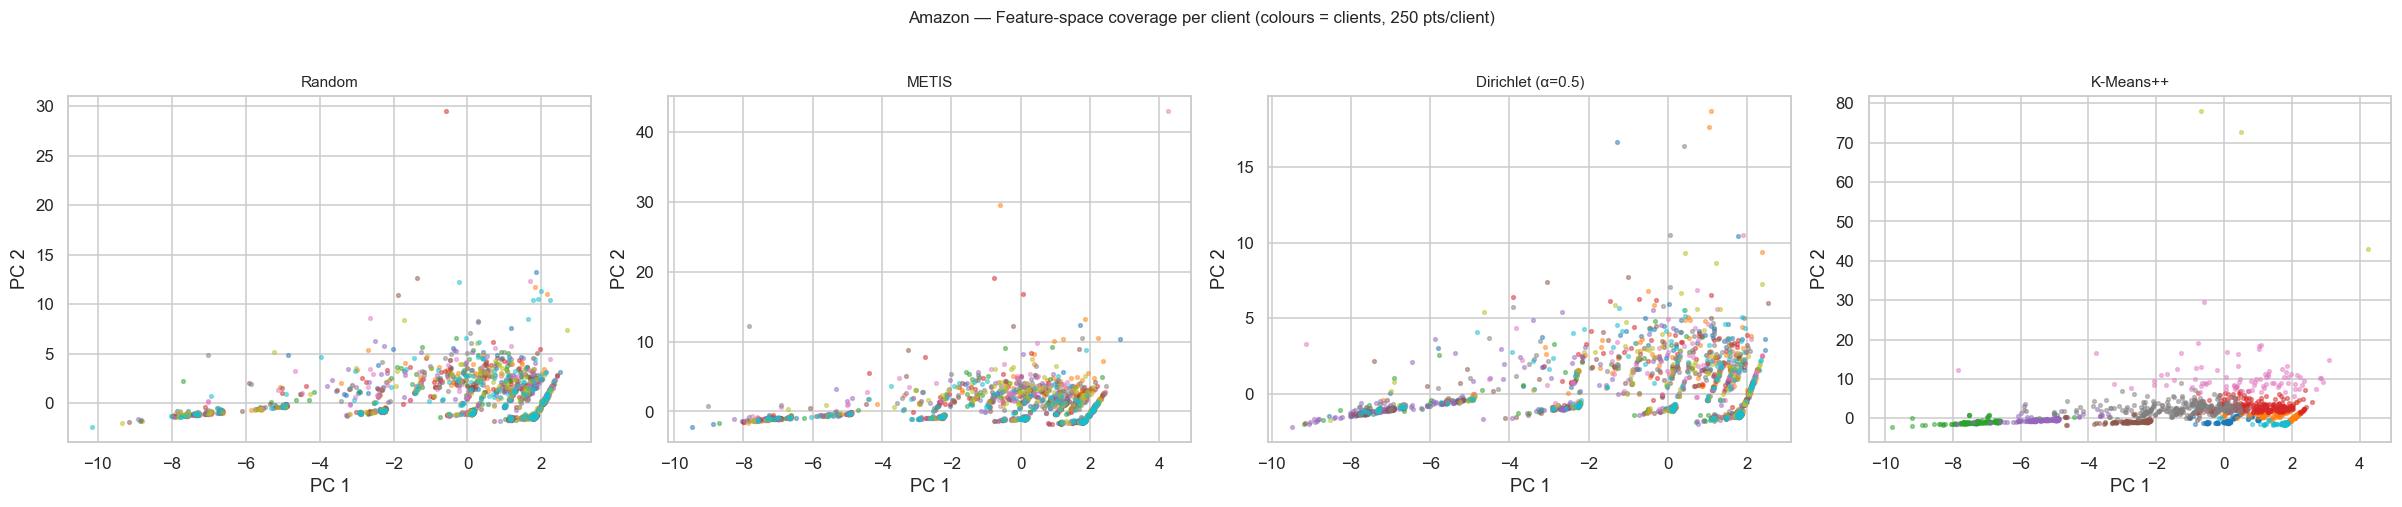

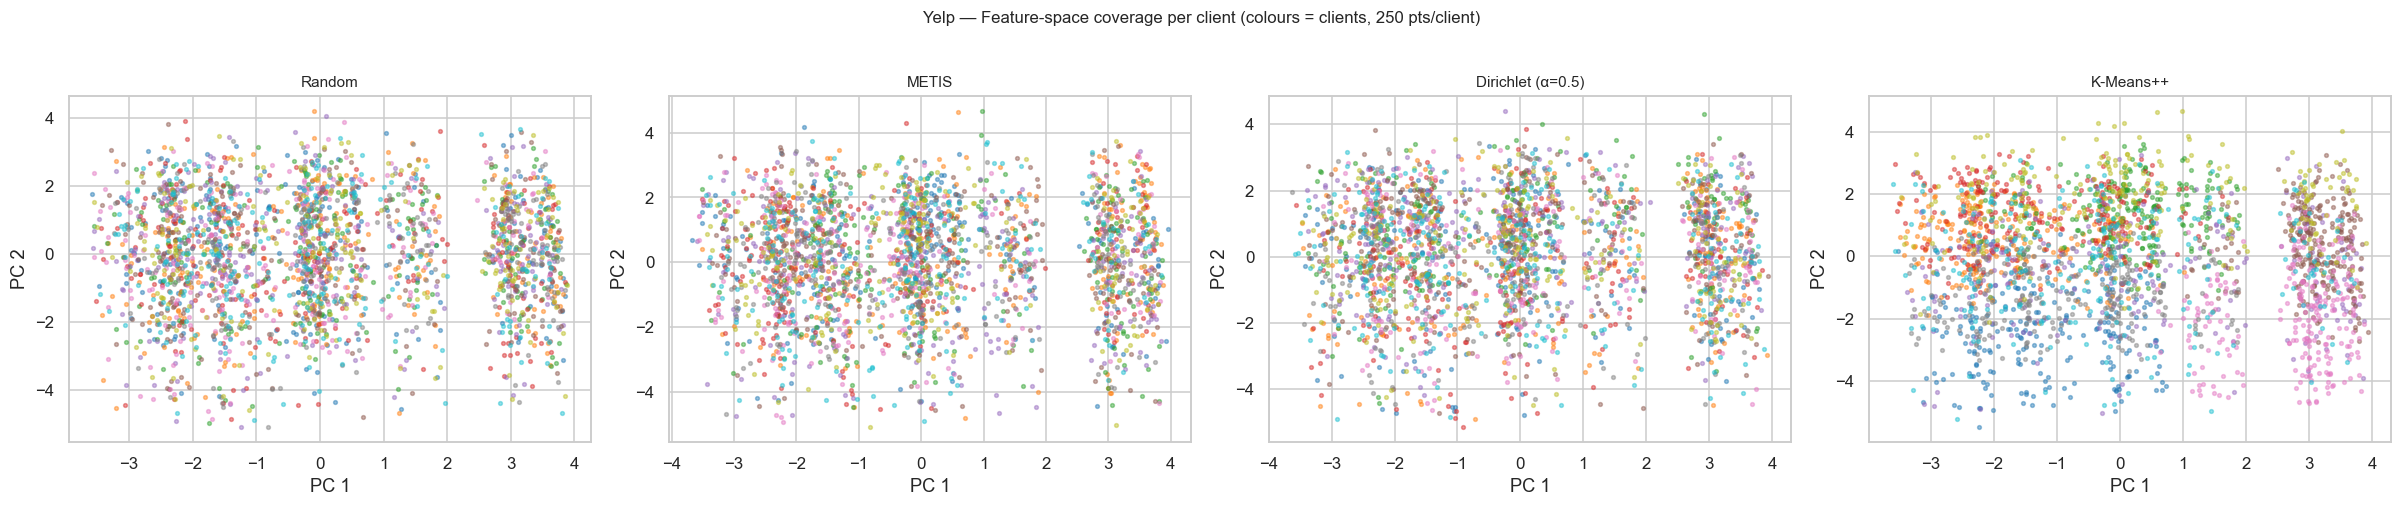

In [21]:
def plot_pca_by_partition(ds_name, graphs, all_partitions, methods, n_clients, seed, n_per_client=250):
    np.random.seed(seed)
    X_full = graphs[ds_name]["features"].numpy()

    # Fit PCA once on all data
    X_std_full = StandardScaler().fit_transform(X_full)
    pca = PCA(n_components=2, random_state=seed).fit(X_std_full)

    cmap = plt.get_cmap("tab10")
    fig, axes = plt.subplots(1, len(methods), figsize=(5.5 * len(methods), 4.5))

    for ax, method in zip(axes, methods):
        parts = all_partitions[ds_name][method]
        for cid in range(n_clients):
            gids = parts[cid].ndata["_ID"].numpy()
            idx  = np.random.choice(len(gids), min(n_per_client, len(gids)), replace=False)
            pts  = pca.transform(X_std_full[gids[idx]])
            ax.scatter(pts[:, 0], pts[:, 1], s=6, alpha=0.45, c=[cmap(cid / n_clients)])

        ax.set_title(METHOD_LABELS[method], fontsize=10)
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")

    plt.suptitle(
        f"{ds_name.capitalize()} — Feature-space coverage per client (colours = clients, {n_per_client} pts/client)",
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    plt.show()

plot_pca_by_partition("amazon", graphs, all_partitions, METHODS, N_CLIENTS, SEED)
plot_pca_by_partition("yelp",   graphs, all_partitions, METHODS, N_CLIENTS, SEED)

### 5.6 Client Subgraph Structural Analysis

We apply the same structural metrics computed for the full graph in §2 to each client's local subgraph: density, average and max in-degree, edge homophily, number of weakly connected components (WCC), and largest-WCC fraction.

This reveals how partitioning strategy affects the **quality of the local graph** that each client receives:
- **Density / degree**: do clients receive dense enough subgraphs for meaningful message passing, or do most edges disappear as cross-partition cuts?
- **Homophily**: does the local fraud/legit connectivity pattern mirror the global graph?
- **WCC fragmentation**: are client subgraphs well-connected (one dominant WCC) or shattered into many small components?

Because random/Dirichlet/K-Means methods lose ~80–90% of edges (§5.4), their local subgraphs are expected to be very sparse and fragmented. METIS, by minimising cut edges, should produce much denser and better-connected local graphs.

In [22]:
def compute_client_stats(g_sub):
    n = g_sub.num_nodes()
    m = g_sub.num_edges()
    labels_sub = g_sub.ndata["label"].long()

    in_deg = g_sub.in_degrees().float()

    src, dst = g_sub.edges()
    homophily = (labels_sub[src] == labels_sub[dst]).float().mean().item() if m > 0 else float("nan")

    adj = sp.csr_matrix(
        (np.ones(m, dtype=np.float32), (src.numpy(), dst.numpy())), shape=(n, n)
    )
    adj_sym = ((adj + adj.T) > 0).astype(np.float32)
    n_comp, comp_lbls = sp_cc(adj_sym, directed=False)
    largest_cc = int(np.bincount(comp_lbls).max()) / n if n > 0 else 0.0

    return {
        "nodes":          n,
        "edges":          m,
        "density":        m / (n * (n - 1)) if n > 1 else 0.0,
        "avg_in_deg":     in_deg.mean().item(),
        "max_in_deg":     float(in_deg.max().item()),
        "homophily":      homophily,
        "n_wcc":          n_comp,
        "largest_cc_pct": largest_cc,
    }


print(f"Computing structural stats for all client subgraphs...\n")
client_stats = {}
for ds_name in ["amazon", "yelp"]:
    client_stats[ds_name] = {}
    for method in METHODS:
        parts = all_partitions[ds_name][method]
        client_stats[ds_name][method] = [compute_client_stats(parts[cid]) for cid in range(N_CLIENTS)]
    print(f"  {ds_name} done")

print("\nDone.\n")

# ── Tabella riassuntiva: media su tutti i client ─────────────────────────────
SKEYS  = ["nodes",     "edges",      "density",  "avg_in_deg", "max_in_deg", "homophily", "n_wcc",   "largest_cc_pct"]
SFMTS  = ["{:>9,.0f}", "{:>11,.0f}", "{:>11.2e}", "{:>11.1f}", "{:>11.0f}",  "{:>11.4f}", "{:>8.1f}", "{:>14.1%}"]
SNAMES = ["Nodes",     "Edges",      "Density",   "Avg in-deg", "Max in-deg", "Homophily", "# WCC",   "Largest CC %"]

for ds_name in ["amazon", "yelp"]:
    print(f"\n{'─'*95}")
    print(f"  {ds_name.upper()}  —  media per-client su {N_CLIENTS} client  (ultima riga = grafo intero)")
    print(f"{'─'*95}")
    header = f"  {'Method':<22}" + "".join(f"  {n:>13}" for n in SNAMES)
    print(header)
    print("  " + "─" * (len(header) - 2))

    for method in METHODS:
        row = f"  {METHOD_LABELS[method]:<22}"
        for k, fmt in zip(SKEYS, SFMTS):
            vals = [s[k] for s in client_stats[ds_name][method] if not (isinstance(s[k], float) and np.isnan(s[k]))]
            row += "  " + fmt.format(np.mean(vals))
        print(row)

    # Riga di riferimento: grafo intero
    g_ref = stats[ds_name]
    row = f"  {'  ↳ full graph':<22}"
    ref_vals = [g_ref["nodes"], g_ref["edges"], g_ref["density"], g_ref["avg_in_deg"],
                g_ref["max_in_deg"], g_ref["homophily"], g_ref["n_wcc"], g_ref["largest_cc_pct"]]
    for v, fmt in zip(ref_vals, SFMTS):
        row += "  " + fmt.format(v)
    print(row)

Computing structural stats for all client subgraphs...

  amazon done
  yelp done

Done.


───────────────────────────────────────────────────────────────────────────────────────────────
  AMAZON  —  media per-client su 10 client  (ultima riga = grafo intero)
───────────────────────────────────────────────────────────────────────────────────────────────
  Method                          Nodes          Edges        Density     Avg in-deg     Max in-deg      Homophily          # WCC   Largest CC %
  ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  Random                      1,194       88,410     6.19e-02         73.9          631       0.9534       5.7           99.6%
  METIS                       1,194      227,579     1.58e-01        189.5          779       0.9278       1.1          100.0%
  Dirichlet (α=0.5)           1,194      134,622     5.59e-02         76.0          610       0.9284

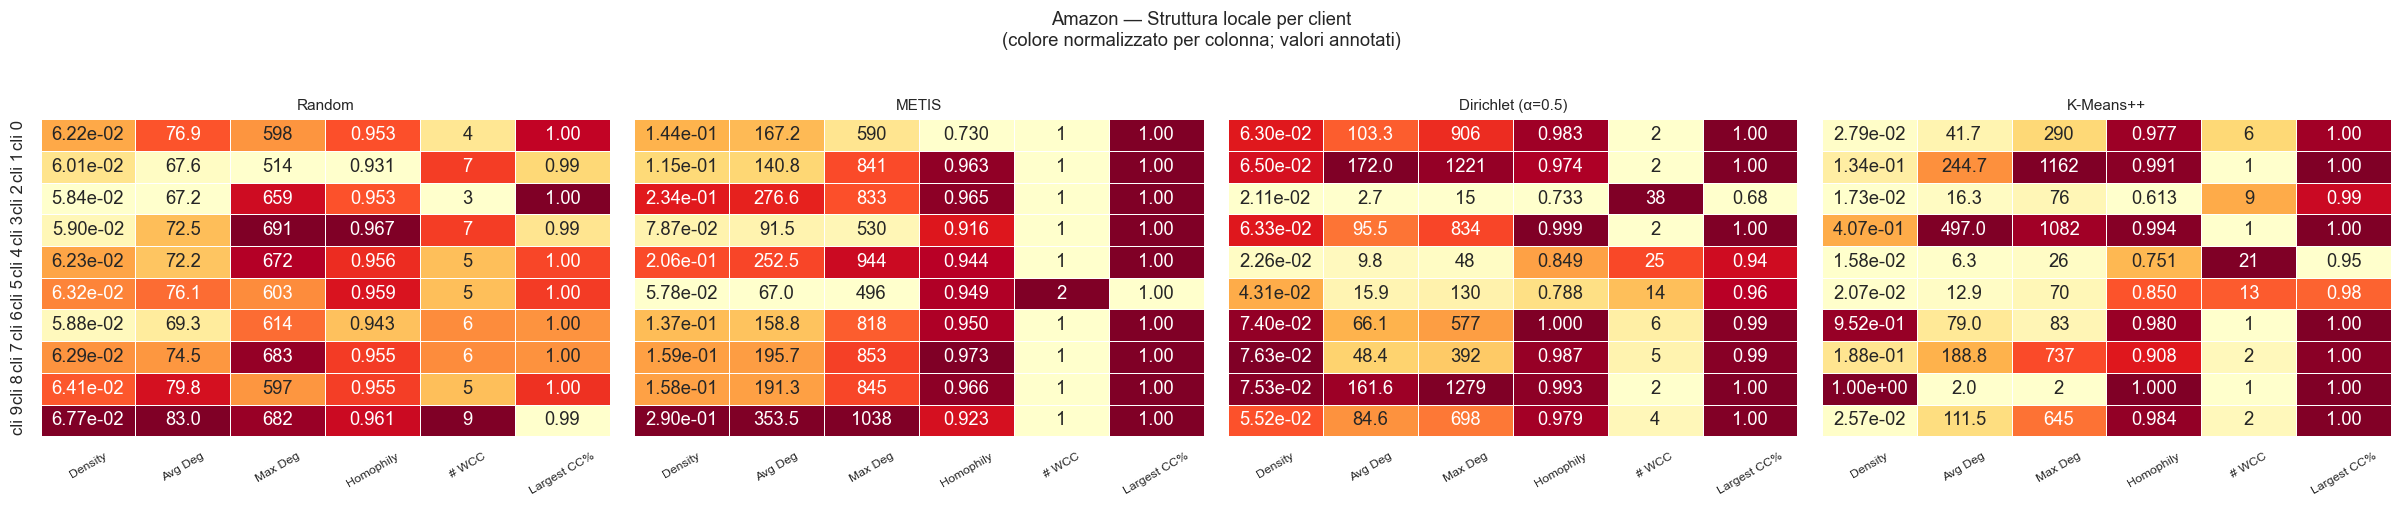

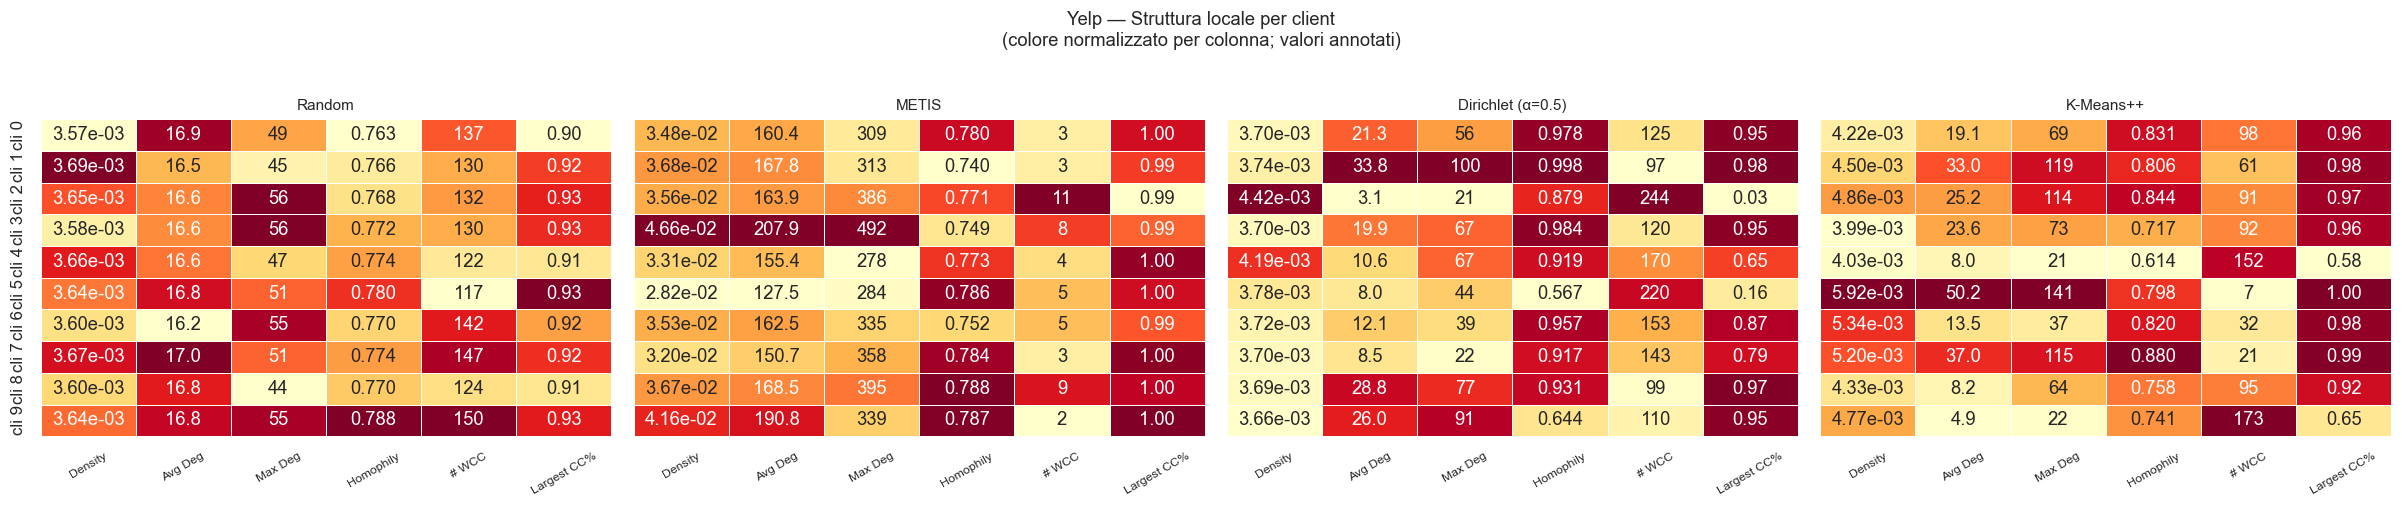

In [23]:
STRUCT_KEYS = ["density", "avg_in_deg", "max_in_deg", "homophily", "n_wcc", "largest_cc_pct"]
STRUCT_LBLS = ["Density", "Avg Deg", "Max Deg", "Homophily", "# WCC", "Largest CC%"]
STRUCT_FMTS = [".2e",     ".1f",     ".0f",     ".3f",       ".0f",   ".2f"]

for ds_name in ["amazon", "yelp"]:
    fig, axes = plt.subplots(1, 4, figsize=(22, 4.5), sharey=True)

    for ax, method in zip(axes, METHODS):
        sl = client_stats[ds_name][method]
        mat = np.array([[s[k] for k in STRUCT_KEYS] for s in sl], dtype=float)

        # Normalizza per colonna per il colore (scale diverse tra metriche)
        col_min = np.nanmin(mat, axis=0, keepdims=True)
        col_max = np.nanmax(mat, axis=0, keepdims=True)
        mat_norm = (mat - col_min) / np.clip(col_max - col_min, 1e-15, None)

        # Annotazioni con valori reali
        annot = np.empty_like(mat, dtype=object)
        for ci in range(N_CLIENTS):
            for mi, fmt in enumerate(STRUCT_FMTS):
                v = mat[ci, mi]
                annot[ci, mi] = format(v, fmt) if not np.isnan(v) else "—"

        sns.heatmap(
            mat_norm, ax=ax, cmap="YlOrRd", vmin=0, vmax=1,
            annot=annot, fmt="", linewidths=0.4,
            xticklabels=STRUCT_LBLS,
            yticklabels=[f"cli {i}" for i in range(N_CLIENTS)],
            cbar=False,
        )
        ax.set_title(METHOD_LABELS[method], fontsize=10)
        ax.tick_params(axis="x", rotation=30, labelsize=8)
        if ax != axes[0]:
            ax.set_ylabel("")

    plt.suptitle(
        f"{ds_name.capitalize()} — Struttura locale per client\n"
        f"(colore normalizzato per colonna; valori annotati)",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.show()

---
## 6. Summary & Conclusions

### Dataset characteristics

| Property | Amazon | Yelp |
|----------|--------|------|
| Scale | ~11k nodes, ~4M edges | ~45k nodes, ~7M edges |
| Feature dim | 25 | 32 |
| Fraud rate | ~9% | ~14% |
| Graph type | Very dense, few WCC | Dense, single WCC |
| Homophily | Moderate | Low–Moderate |

### Partitioning summary

| Property | Random | METIS | Dirichlet | K-Means++ |
|----------|--------|-------|-----------|----------|
| Node balance | ✅ Excellent | ✅ Good | ⚠️ Variable | ⚠️ Variable |
| Label heterogeneity | ✅ Near-IID | ⚠️ Mild | ❌ High | ❌ Medium-High |
| Edge preservation | ❌ High loss | ✅ Minimal loss | ❌ High loss | ❌ High loss |
| Feature heterogeneity | ✅ Low | ⚠️ Mild | ⚠️ Mild | ❌ High |

### Implications for the FL experiments

1. **Random**: a baseline that verifies FedAvg can converge in the IID case. Should give the best global model performance.
2. **METIS**: minimises edge cut — clients have more complete local graph structure. May perform better on datasets where graph structure is critical (low feature separability). Mild non-IID due to community structure.
3. **Dirichlet**: the standard FL non-IID benchmark. Some clients will have near-zero fraud samples → high local class imbalance → class-weighted loss becomes very important. FedAvg convergence is slower and the global model may be biased.
4. **K-Means++**: non-IID driven by feature space. Clients operate in different feature regimes, so the global model must generalise across feature sub-distributions — a different challenge from label skew. Interesting to see if the global model or local models perform better here.